# 1. Import the libraries:

In [1]:
%pwd

'D:\\ML and AI Engineer\\Projects\\An-end-to-end-customer-churn-prediction-model\\research'

In [5]:
import os
os.chdir("..")
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder, RobustScaler, OrdinalEncoder
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.feature_selection import mutual_info_classif
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold, StratifiedKFold, RepeatedStratifiedKFold, cross_val_score

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
%matplotlib inline

In [6]:
%pwd

'D:\\ML and AI Engineer\\Projects\\An-end-to-end-customer-churn-prediction-model'

# 2. Load the data:

In [7]:
clipped_train = pd.read_parquet("Artifacts/feature_engineering/data_clipped/train.parquet")
clipped_test = pd.read_parquet("Artifacts/feature_engineering/data_clipped/test.parquet")

unclipped_train = pd.read_parquet("Artifacts/feature_engineering/data_unclipped/train.parquet")
unclipped_test = pd.read_parquet("Artifacts/feature_engineering/data_unclipped/test.parquet")

# 3. Common functions:

### To create dependent(y) and independent(X) features:

In [8]:
def create_dep_indep_features(df:pd.DataFrame):
    """
    Splits the data into dependent(y) and independent(X) features:
    """
    df.dropna(inplace=True)
    X = df.drop(columns=['customerid', 'churn'])
    y = df['churn']
    return X, y   

### To define the column groups based on the `dtypes()`:

In [9]:
def separate_col_by_dtypes(df:pd.DataFrame) -> list():
    """
    Returns the numerical and categorical feature names as list:
    """
    numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_features = df.select_dtypes(include=['object', 'string']).columns.tolist()
    return (numerical_features, categorical_features)

### For visual testing of multi-collinearity via heatmap of correlation matrix|:

In [10]:
def corr_heatmap(df:pd.DataFrame, branch_name:str):
    corr = df.corr()
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                square=True, ax=ax)
    ax.set_title(f"Feature Correlation Matrix - {branch_name}")
    plt.tight_layout()

    return fig, corr

### Features with correlation >= abs(0.8):

In [11]:
def corr_above_threshold(df:pd.DataFrame, thredhold=0.8):
    """
    Checks if any features have a correlation >= abs(0.8):
    """
    printed = set()
    for i in range(len(corr.columns)):
        for j in range(i + 1, len(corr.columns)):
            r = corr.iloc[i, j]
            if abs(r) > thredhold:
                col_i = corr.columns[i]
                col_j = corr.columns[j]
                if (col_i, col_j) not in printed:
                    print(f"  {col_i} – {col_j}: {r:.3f}")
                    printed.add((col_i, col_j))  
    if len(printed) == 0:
        print(f"None of the features have correlation greated than the defined threshold: {thredhold}")
        return printed
    else:
        return printed

#### `Multi-collinearity` test with `variance_inflation_factor`

In [12]:
def compute_vif(df:pd.DataFrame, features:list) -> pd.DataFrame:
    X_num = df[features].copy()
    vif_data= pd.DataFrame({
        'feature': features,
        'VIF': [variance_inflation_factor(X_num.values, i) for i in range(X_num.shape[1])]
    })
    return vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

### Drop features with VIF > 10 to avoid multi-collinearity:

In [13]:
def drop_high_vif(X: pd.DataFrame, features: list,
                  threshold: float = 10.0) -> list:
    features = features.copy()
    print(f"Starting VIF filter | threshold: {threshold}\n")
    while True:
        vif_df = compute_vif(X, features)
        max_vif   = vif_df.iloc[0]['VIF']
        max_feat  = vif_df.iloc[0]['feature']
        if max_vif <= threshold:
            print(f"All VIFs at or below {threshold}. Done.\n")
            break
        print(f"Dropping '{max_feat}' — VIF: {max_vif:.2f}")
        features.remove(max_feat)
    print(vif_df.to_string(index=False))
    return features

### Mutual Information:

In [14]:
def compute_mutual_info(X: pd.DataFrame, y: pd.Series,
                        numerical_features: list,
                        categorical_features: list) -> pd.DataFrame:
    
    all_features = numerical_features + categorical_features
    X_mi = X[all_features].copy()
    
    # Encode country as integer for MI calculation
    X_mi['country'] = X_mi['country'].astype('category').cat.codes
    
    # discrete_features: True for categorical, False for continuous
    discrete_mask = [False] * len(numerical_features) + [True] * len(categorical_features)
    
    mi_scores = mutual_info_classif(
        X_mi, y,
        discrete_features=discrete_mask,
        random_state=42
    )
    
    mi_df = pd.DataFrame({
        'feature':  all_features,
        'MI_score': mi_scores
    }).sort_values('MI_score', ascending=False).reset_index(drop=True)
    
    return mi_df


def plot_mutual_info(mi_df: pd.DataFrame, branch_name:str):
    plt.figure(figsize=(10, 6))
    colors = ['limegreen' if s > 0.01 else 'firebrick'
              for s in mi_df['MI_score']]
    plt.barh(mi_df['feature'], mi_df['MI_score'], color=colors)
    plt.xlabel('Mutual Information Score')
    plt.title(f'Feature Relevance to Churn (Mutual Information): {branch_name}')
    plt.axvline(x=0.01, color='black', linestyle='--',
                linewidth=1, label='Threshold (0.01)')
    plt.legend()
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


### Testing Scaling Techniques:

In [15]:
def test_scaling_techniques(X_train:pd.DataFrame, numerical_feature:list, 
                            categorical_feature:list, y_train:pd.Series) -> dict:
    """
    Runs the experiment through 3 scaling techniques and 1 encoding techniques using a baseline model KNN:
    """
    results = {}

    base_model = KNeighborsClassifier()
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
    
    
    
    scalers = {
        "RobustScaler": RobustScaler(),
        "StandardScaler": StandardScaler(),
        "MinMaxScaler": MinMaxScaler()
    }
    
    for scaler_name, scaler in scalers.items():
        preprocessor = ColumnTransformer([
            ('num', scaler, numerical_feature),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
        ])
    
        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('clf', base_model)
        ])
    
        cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
        results[scaler_name] = cv_scores
        print(f"Scaler:{scaler_name} | Encoder:OneHotEncoder | Avg F1: {np.mean(cv_scores)*100:.2f}% | STD: ±{np.std(cv_scores)*100:.2f}%.")
    return results

### Plot the F1-Score on the training data:

In [16]:
def plot_results(results:dict):
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.boxplot(
        results.values(),
        tick_labels=results.keys(),
        patch_artist=True
    )
    
    ax.set_title('Scaler Comparison — Cross-Validation F1 (Training Data Only)')
    ax.set_ylabel('F1 Score')
    ax.set_xlabel('Scaler')
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x*100:.1f}%')
    )
    plt.tight_layout()
    plt.show()

# 4. Working on `Clipped Data`:

In [17]:
X_train, y_train = create_dep_indep_features(df=clipped_train)
X_test, y_test = create_dep_indep_features(df=clipped_test)
numerical_features, categorical_features = separate_col_by_dtypes(df=X_train)

In [18]:
print(f"X_train:{X_train.shape} | y_train:{y_train.shape}\n")
print(f"Numerical Columns:{numerical_features}\n\nCategorical Columns:{categorical_features}")

X_train:(4384, 13) | y_train:(4384,)

Numerical Columns:['order_frequency', 'total_monetary_value', 'total_quantity_abs', 'total_order_issues', 'avg_order_value', 'avg_quantity_per_order', 'customer_order_issue_rate', 'recency', 'tenure', 'avg_stockcode_issue_rate', 'max_stockcode_issue_rate', 'total_orders_made_for_stock']

Categorical Columns:['country']


## 4.1 Correlation & Multi-Collinearity Checks:

### 4.1.1 Correlation:

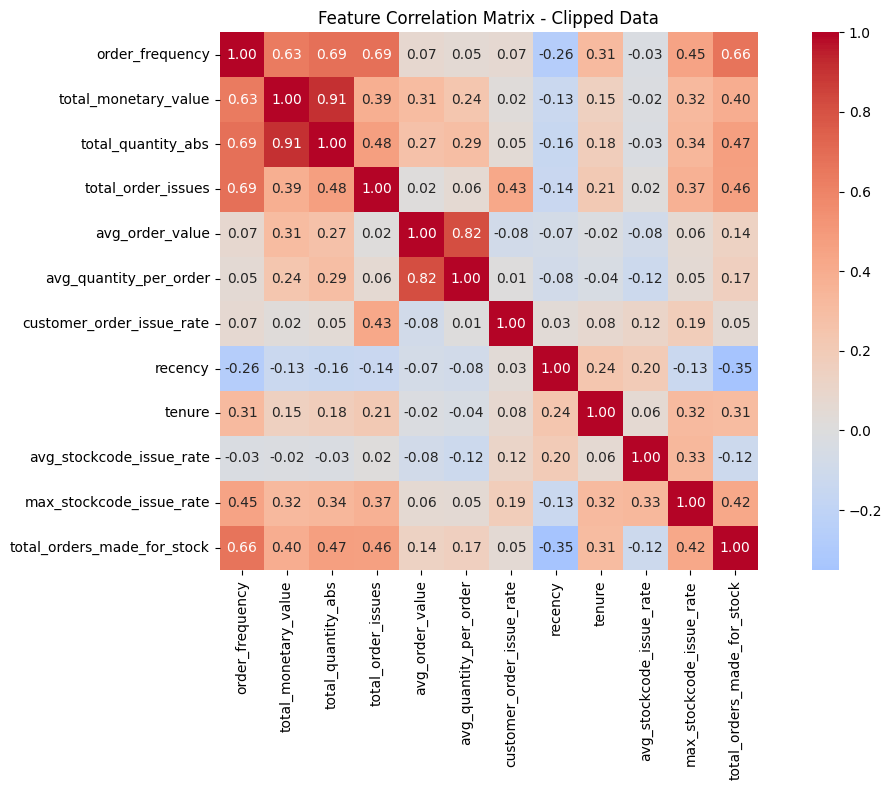

In [19]:
fig, corr = corr_heatmap(df=X_train[numerical_features], branch_name="Clipped Data")

In [20]:
corr.head()

,order_frequency,total_monetary_value,total_quantity_abs,total_order_issues,avg_order_value,avg_quantity_per_order,customer_order_issue_rate,recency,tenure,avg_stockcode_issue_rate,max_stockcode_issue_rate,total_orders_made_for_stock
order_frequency,1.000000,0.632281,0.687898,0.687947,0.072513,0.054195,0.067488,-0.264037,0.314972,-0.027695,0.448251,0.663984
total_monetary_value,0.632281,1.000000,0.906567,0.385180,0.312877,0.235153,0.018774,-0.132044,0.153349,-0.017178,0.320391,0.395367
total_quantity_abs,0.687898,0.906567,1.000000,0.475990,0.266467,0.292199,0.046803,-0.155514,0.178395,-0.027520,0.342221,0.474323
total_order_issues,0.687947,0.385180,0.475990,1.000000,0.015379,0.061042,0.429096,-0.144424,0.214819,0.015111,0.370366,0.463755
avg_order_value,0.072513,0.312877,0.266467,0.015379,1.000000,0.820367,-0.083334,-0.070859,-0.015865,-0.083185,0.062553,0.136625


In [21]:
corr_above_threshold(df=corr)

  total_monetary_value – total_quantity_abs: 0.907
  avg_order_value – avg_quantity_per_order: 0.820


{('avg_order_value', 'avg_quantity_per_order'),
 ('total_monetary_value', 'total_quantity_abs')}

So, there are two features which has higher correlation to each other which could lead in multi-collinearity.

### 4.1.2 Multi-collinearity:

In [22]:
vif_values = compute_vif(df=X_train, features=numerical_features)
print(f"The data-frame has a total of {len(numerical_features)} numerical features. Below, the table represents the calculated VIF values:"
     f"{vif_values}")

The data-frame has a total of 12 numerical features. Below, the table represents the calculated VIF values:                        feature       VIF
0                        tenure  9.432592
1            total_quantity_abs  8.392291
2          total_monetary_value  7.346603
3        avg_quantity_per_order  6.341679
4                       recency  5.820649
5               avg_order_value  5.643128
6               order_frequency  5.550459
7      max_stockcode_issue_rate  3.799277
8   total_orders_made_for_stock  3.706678
9            total_order_issues  2.972992
10     avg_stockcode_issue_rate  1.804312
11    customer_order_issue_rate  1.597849


In [23]:
features = drop_high_vif(X=X_train, features=numerical_features)

Starting VIF filter | threshold: 10.0

All VIFs at or below 10.0. Done.

                    feature      VIF
                     tenure 9.432592
         total_quantity_abs 8.392291
       total_monetary_value 7.346603
     avg_quantity_per_order 6.341679
                    recency 5.820649
            avg_order_value 5.643128
            order_frequency 5.550459
   max_stockcode_issue_rate 3.799277
total_orders_made_for_stock 3.706678
         total_order_issues 2.972992
   avg_stockcode_issue_rate 1.804312
  customer_order_issue_rate 1.597849


In [24]:
print("=== VIF Before Dropping ===")
print(compute_vif(X_train, numerical_features).to_string(index=False))

print("\n=== Iterative VIF Filtering ===")
numerical_features_vif_clean = drop_high_vif(X_train, numerical_features,
                                              threshold=10.0)
print("\n=== Cleaned Numerical Features ===")
numerical_features_vif_clean

=== VIF Before Dropping ===
                    feature      VIF
                     tenure 9.432592
         total_quantity_abs 8.392291
       total_monetary_value 7.346603
     avg_quantity_per_order 6.341679
                    recency 5.820649
            avg_order_value 5.643128
            order_frequency 5.550459
   max_stockcode_issue_rate 3.799277
total_orders_made_for_stock 3.706678
         total_order_issues 2.972992
   avg_stockcode_issue_rate 1.804312
  customer_order_issue_rate 1.597849

=== Iterative VIF Filtering ===
Starting VIF filter | threshold: 10.0

All VIFs at or below 10.0. Done.

                    feature      VIF
                     tenure 9.432592
         total_quantity_abs 8.392291
       total_monetary_value 7.346603
     avg_quantity_per_order 6.341679
                    recency 5.820649
            avg_order_value 5.643128
            order_frequency 5.550459
   max_stockcode_issue_rate 3.799277
total_orders_made_for_stock 3.706678
         total_

['order_frequency',
 'total_monetary_value',
 'total_quantity_abs',
 'total_order_issues',
 'avg_order_value',
 'avg_quantity_per_order',
 'customer_order_issue_rate',
 'recency',
 'tenure',
 'avg_stockcode_issue_rate',
 'max_stockcode_issue_rate',
 'total_orders_made_for_stock']

No features have been dropped since the VIF didn't cross the defined threshold of `10`.

## 4.2 Mutual Information:

=== Mutual Information Scores ===
                    feature  MI_score
            order_frequency  0.125664
       total_monetary_value  0.115125
         total_quantity_abs  0.104112
                    recency  0.080149
total_orders_made_for_stock  0.075252
  customer_order_issue_rate  0.071840
     avg_quantity_per_order  0.046071
         total_order_issues  0.043682
   max_stockcode_issue_rate  0.027463
                     tenure  0.017615
   avg_stockcode_issue_rate  0.016052
            avg_order_value  0.008408
                    country  0.007609


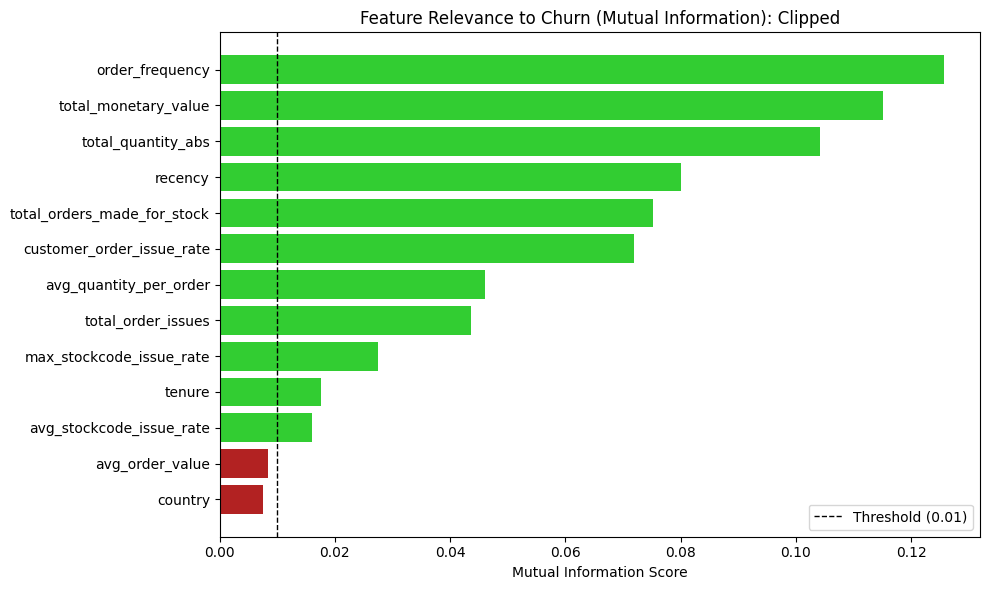

--------------------------------------------------

Features kept after MI filter (11): ['order_frequency', 'total_monetary_value', 'total_quantity_abs', 'recency', 'total_orders_made_for_stock', 'customer_order_issue_rate', 'avg_quantity_per_order', 'total_order_issues', 'max_stockcode_issue_rate', 'tenure', 'avg_stockcode_issue_rate']
--------------------------------------------------
Features dropped (2):  ['avg_order_value', 'country']


In [25]:
mi_df = compute_mutual_info(
    X_train, y_train,
    numerical_features=numerical_features_vif_clean,
    categorical_features=categorical_features
)

print("=== Mutual Information Scores ===")
print(mi_df.to_string(index=False))
plot_mutual_info(mi_df, branch_name='Clipped')
print(f"{'-' * 50}")
# Features to keep: MI score above 0.01
features_to_keep = mi_df[mi_df['MI_score'] > 0.01]['feature'].tolist()
print(f"\nFeatures kept after MI filter ({len(features_to_keep)}): {features_to_keep}")
print(f"{'-' * 50}")
# Features dropped: MI score at or below 0.01
features_dropped = mi_df[mi_df['MI_score'] <= 0.01]['feature'].tolist()
print(f"Features dropped ({len(features_dropped)}):  {features_dropped}")

In [26]:
len(X_train.columns)

13

In [27]:
len(features_to_keep)

11

## 4.3 Testing out scaling features:

For scaling numerical features, I will test these 3 options:
1. Min-max scaler
2. Standardization
3. RobustScaler

But, to use `standardization`, it is important to have features that follow a `normal-dirstribution` for a better results, below,
none of the features follow a `normal/gaussian distribution`, so, i will be testing out all the scaling techniques, and later finalize the method based on the bsae-model's (`KNN`) performance on the testing set.

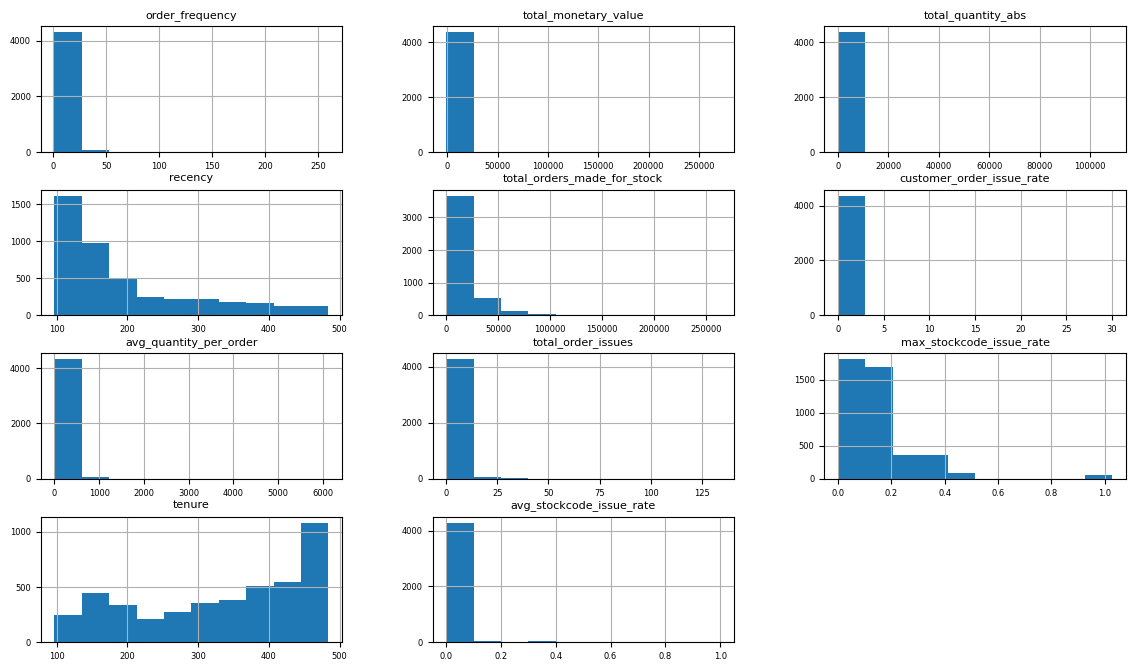

In [28]:
fig = X_train[features_to_keep].hist(xlabelsize=6, ylabelsize=6, figsize=(14, 8))
[x.title.set_size(8) for x in fig.ravel()]
plt.show()

### 4.3.1 Testing out multiple scaling techniques:

In [29]:
results = test_scaling_techniques(X_train=X_train, y_train=y_train, numerical_feature=numerical_features, categorical_feature=categorical_features)

Scaler:RobustScaler | Encoder:OneHotEncoder | Avg F1: 82.38% | STD: ±0.80%.
Scaler:StandardScaler | Encoder:OneHotEncoder | Avg F1: 81.74% | STD: ±0.74%.
Scaler:MinMaxScaler | Encoder:OneHotEncoder | Avg F1: 80.63% | STD: ±1.09%.


### 4.3.2 Plotting the F1-score of the tested scaling techniques on Training data:

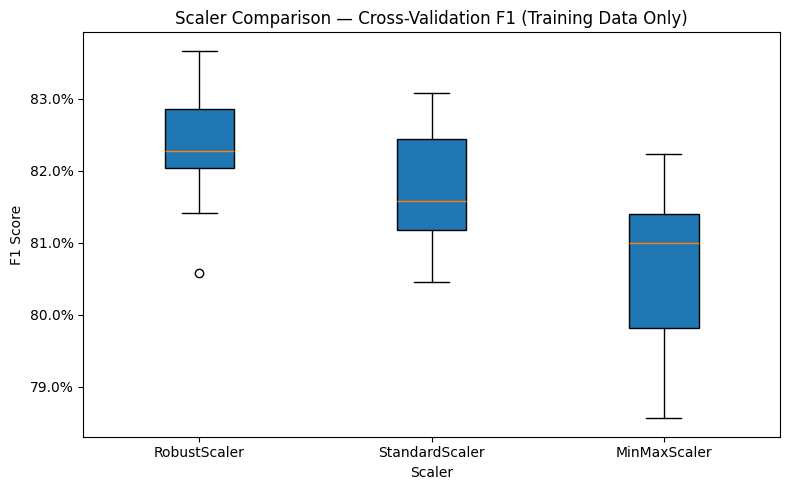

In [30]:
plot_results(results)

#### Findings:

`RobustScaler()` is the best scaling techniques so far on the `clipped data training set` with the metrics of:
`Avg F1: 82.38% | STD: ±0.80%.`

### 4.3.3 Predicting on the `test-set`:

In [31]:
preprocessor = ColumnTransformer([
        ('num', RobustScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore',
                              sparse_output=False), categorical_features)
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', KNeighborsClassifier())
])

# Fit on the training set:
pipeline.fit(X_train, y_train)         

,steps,"[('preprocessor', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [32]:
y_pred_test = pipeline.predict(X_test)
y_pred_train = pipeline.predict(X_train)
print(f"Testing data | F1-score:{f1_score(y_test, y_pred_test)*100:.2f}%")
print(f"Training data | F1-score: {f1_score(y_train, y_pred_train)*100:.2f}%")
print(f"{'-' * 60}")
print(f"With RobustScaler and KNN as the base model, we can achieve a minimum F1-score of: {results['RobustScaler'].min()*100:.2f}%"
     f" and the maximum score of: {results['RobustScaler'].max()*100:.2f}%")

Testing data | F1-score:82.93%
Training data | F1-score: 87.26%
------------------------------------------------------------
With RobustScaler and KNN as the base model, we can achieve a minimum F1-score of: 80.58% and the maximum score of: 83.67%


# 5. Working with Unclipped Data:

In [33]:
X_train, y_train = create_dep_indep_features(df=unclipped_train)
X_test, y_test = create_dep_indep_features(df=unclipped_test)
numerical_features, categorical_features = separate_col_by_dtypes(df=X_train)

In [34]:
print(f"X_train:{X_train.shape} | y_train:{y_train.shape}\n")
print(f"Numerical Columns:{numerical_features}\n\nCategorical Columns:{categorical_features}")

X_train:(4384, 13) | y_train:(4384,)

Numerical Columns:['order_frequency', 'total_monetary_value', 'total_quantity_abs', 'total_order_issues', 'avg_order_value', 'avg_quantity_per_order', 'customer_order_issue_rate', 'recency', 'tenure', 'avg_stockcode_issue_rate', 'max_stockcode_issue_rate', 'total_orders_made_for_stock']

Categorical Columns:['country']


## 5.1 Correlation and Multi-Collinearity Checks:

### 5.1.1 Correlation:

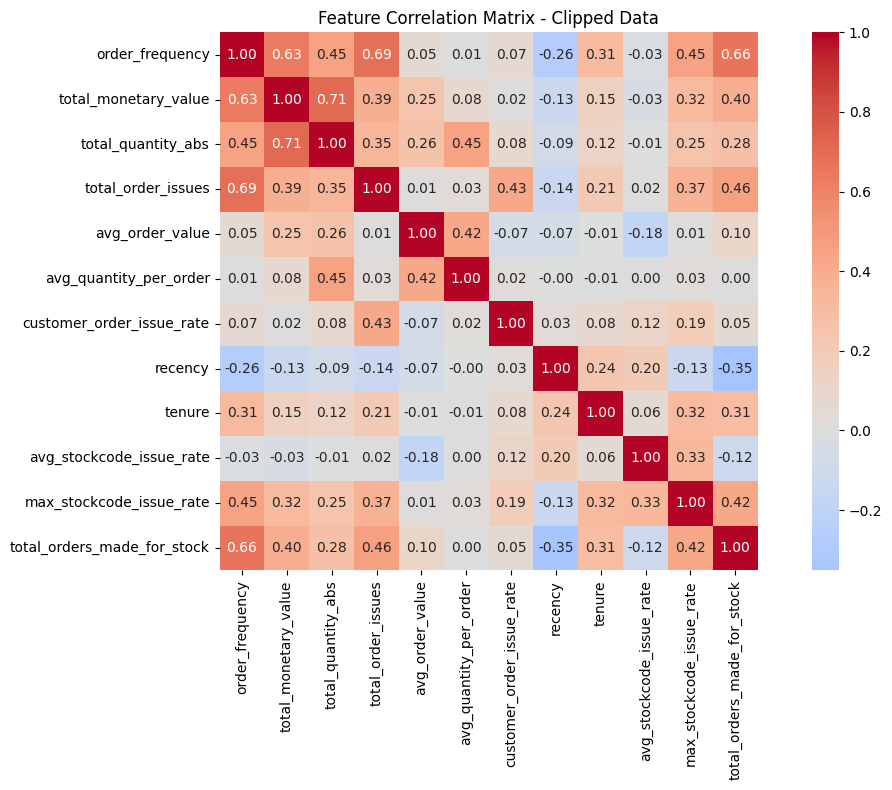

In [35]:
fig, corr = corr_heatmap(df=X_train[numerical_features], branch_name="Clipped Data")

In [36]:
results = corr_above_threshold(df=corr)

None of the features have correlation greated than the defined threshold: 0.8


In [37]:
results

set()

### 5.1.2 Multi-collinearity:

In [38]:
vif_values = compute_vif(df=X_train, features=numerical_features)
print(f"The data-frame has a total of {len(numerical_features)} numerical features. Below, the table represents the calculated VIF values:"
     f"{vif_values}")

The data-frame has a total of 12 numerical features. Below, the table represents the calculated VIF values:                        feature       VIF
0                        tenure  9.382141
1                       recency  5.733288
2               order_frequency  5.380887
3      max_stockcode_issue_rate  3.792036
4          total_monetary_value  3.624568
5   total_orders_made_for_stock  3.554972
6            total_quantity_abs  3.281524
7            total_order_issues  2.956313
8        avg_quantity_per_order  1.867403
9      avg_stockcode_issue_rate  1.843956
10              avg_order_value  1.661510
11    customer_order_issue_rate  1.570638


In [39]:
features = drop_high_vif(X=X_train, features=numerical_features)

Starting VIF filter | threshold: 10.0

All VIFs at or below 10.0. Done.

                    feature      VIF
                     tenure 9.382141
                    recency 5.733288
            order_frequency 5.380887
   max_stockcode_issue_rate 3.792036
       total_monetary_value 3.624568
total_orders_made_for_stock 3.554972
         total_quantity_abs 3.281524
         total_order_issues 2.956313
     avg_quantity_per_order 1.867403
   avg_stockcode_issue_rate 1.843956
            avg_order_value 1.661510
  customer_order_issue_rate 1.570638


In [40]:
print("=== VIF Before Dropping ===")
print(compute_vif(X_train, numerical_features).to_string(index=False))

print("\n=== Iterative VIF Filtering ===")
numerical_features_vif_clean = drop_high_vif(X_train, numerical_features,
                                              threshold=10.0)
print("\n=== Cleaned Numerical Features ===")
numerical_features_vif_clean

=== VIF Before Dropping ===
                    feature      VIF
                     tenure 9.382141
                    recency 5.733288
            order_frequency 5.380887
   max_stockcode_issue_rate 3.792036
       total_monetary_value 3.624568
total_orders_made_for_stock 3.554972
         total_quantity_abs 3.281524
         total_order_issues 2.956313
     avg_quantity_per_order 1.867403
   avg_stockcode_issue_rate 1.843956
            avg_order_value 1.661510
  customer_order_issue_rate 1.570638

=== Iterative VIF Filtering ===
Starting VIF filter | threshold: 10.0

All VIFs at or below 10.0. Done.

                    feature      VIF
                     tenure 9.382141
                    recency 5.733288
            order_frequency 5.380887
   max_stockcode_issue_rate 3.792036
       total_monetary_value 3.624568
total_orders_made_for_stock 3.554972
         total_quantity_abs 3.281524
         total_order_issues 2.956313
     avg_quantity_per_order 1.867403
   avg_stockcod

['order_frequency',
 'total_monetary_value',
 'total_quantity_abs',
 'total_order_issues',
 'avg_order_value',
 'avg_quantity_per_order',
 'customer_order_issue_rate',
 'recency',
 'tenure',
 'avg_stockcode_issue_rate',
 'max_stockcode_issue_rate',
 'total_orders_made_for_stock']

## 5.2 Mutual Information:

=== Mutual Information Scores ===
                    feature  MI_score
            order_frequency  0.125664
       total_monetary_value  0.117527
         total_quantity_abs  0.099246
                    recency  0.080149
total_orders_made_for_stock  0.075252
  customer_order_issue_rate  0.071840
     avg_quantity_per_order  0.058417
         total_order_issues  0.043682
   max_stockcode_issue_rate  0.027463
                     tenure  0.017615
            avg_order_value  0.016286
   avg_stockcode_issue_rate  0.016052
                    country  0.007609


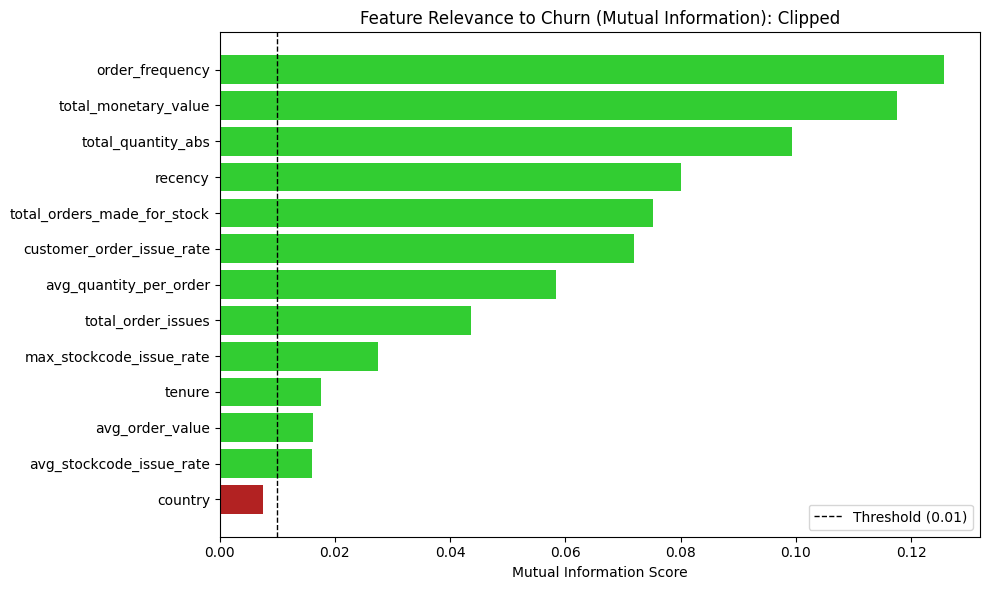

--------------------------------------------------

Features kept after MI filter (12): ['order_frequency', 'total_monetary_value', 'total_quantity_abs', 'recency', 'total_orders_made_for_stock', 'customer_order_issue_rate', 'avg_quantity_per_order', 'total_order_issues', 'max_stockcode_issue_rate', 'tenure', 'avg_order_value', 'avg_stockcode_issue_rate']
--------------------------------------------------
Features dropped (1):  ['country']


In [41]:
mi_df = compute_mutual_info(
    X_train, y_train,
    numerical_features=numerical_features_vif_clean,
    categorical_features=categorical_features
)

print("=== Mutual Information Scores ===")
print(mi_df.to_string(index=False))
plot_mutual_info(mi_df, branch_name='Clipped')
print(f"{'-' * 50}")
# Features to keep: MI score above 0.01
features_to_keep = mi_df[mi_df['MI_score'] > 0.01]['feature'].tolist()
print(f"\nFeatures kept after MI filter ({len(features_to_keep)}): {features_to_keep}")
print(f"{'-' * 50}")
# Features dropped: MI score at or below 0.01
features_dropped = mi_df[mi_df['MI_score'] <= 0.01]['feature'].tolist()
print(f"Features dropped ({len(features_dropped)}):  {features_dropped}")

In [42]:
len(X_train.columns)

13

In [43]:
len(features_to_keep)

12

## 5.3 Testing out scaling features:

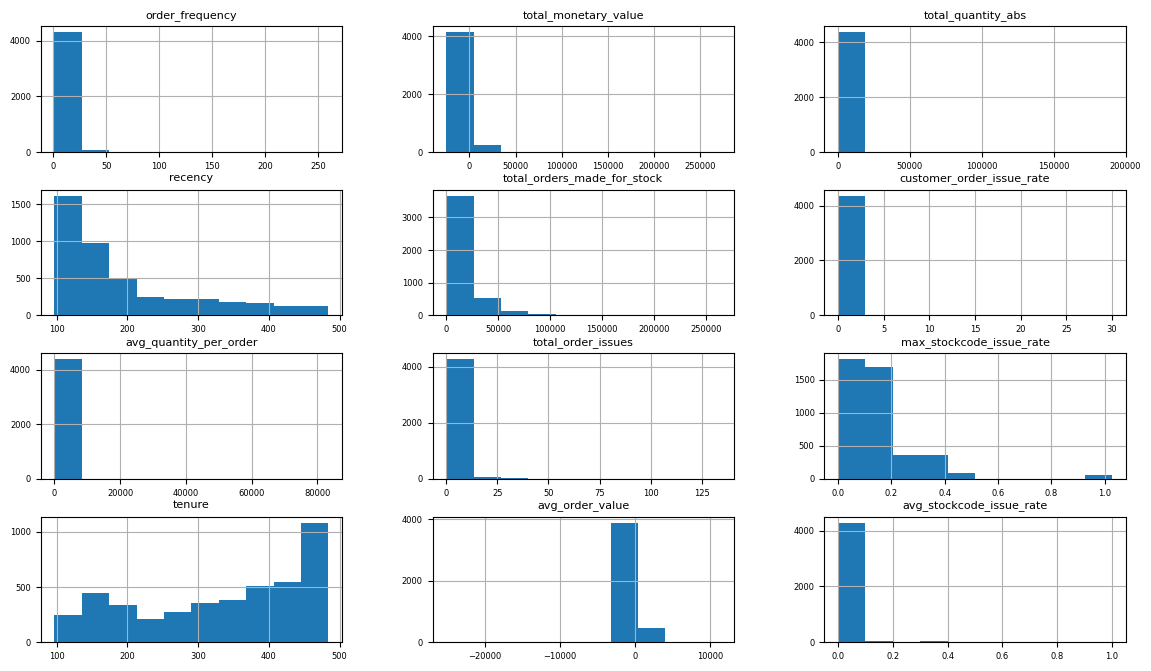

In [44]:
fig = X_train[features_to_keep].hist(xlabelsize=6, ylabelsize=6, figsize=(14, 8))
[x.title.set_size(8) for x in fig.ravel()]
plt.show()

### 5.3.1 Testing features selected by MI:

In [45]:
results = test_scaling_techniques(X_train=X_train, y_train=y_train,
                                 numerical_feature=features_to_keep, categorical_feature=categorical_features)

Scaler:RobustScaler | Encoder:OneHotEncoder | Avg F1: 82.22% | STD: ±0.80%.
Scaler:StandardScaler | Encoder:OneHotEncoder | Avg F1: 81.72% | STD: ±0.95%.
Scaler:MinMaxScaler | Encoder:OneHotEncoder | Avg F1: 80.96% | STD: ±0.84%.


#### Plot the results:

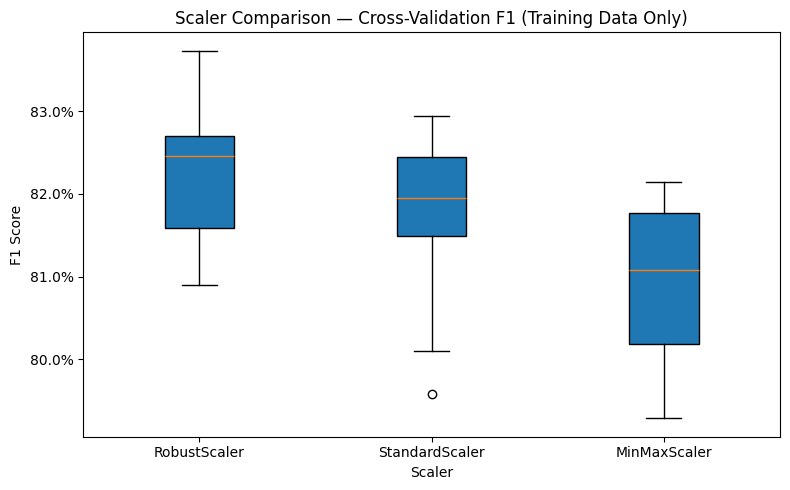

In [46]:
plot_results(results)

### 5.3.1 Testing on all the featuers:

In [47]:
results = test_scaling_techniques(X_train=X_train, y_train=y_train,
                                 numerical_feature=numerical_features, categorical_feature=categorical_features)

Scaler:RobustScaler | Encoder:OneHotEncoder | Avg F1: 82.22% | STD: ±0.80%.
Scaler:StandardScaler | Encoder:OneHotEncoder | Avg F1: 81.72% | STD: ±0.95%.
Scaler:MinMaxScaler | Encoder:OneHotEncoder | Avg F1: 80.96% | STD: ±0.84%.


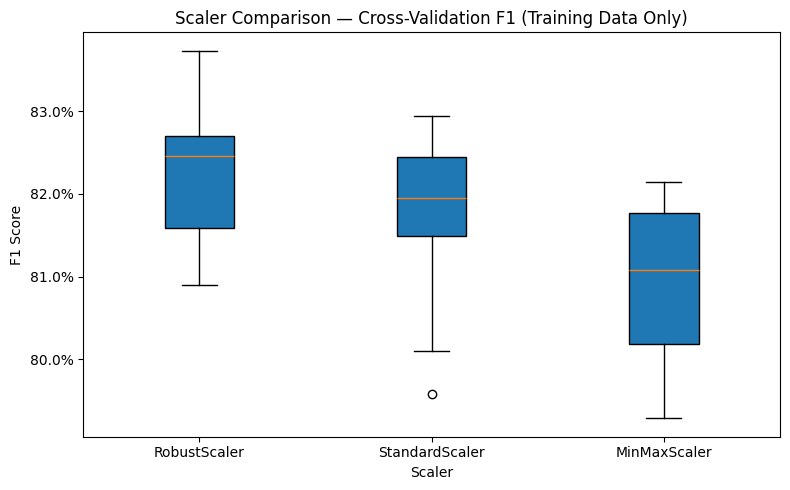

In [48]:
plot_results(results)

The results are identical for both features (`Features from MI or All the features`):

#### Findings:

`RobustScaler()` is the best scaling techniques so far on the `clipped data training set` with the metrics of:
`Avg F1: 82.22% | STD: ±0.80%.`

#### 5.3.4 Predicting on the `test-set`:

In [49]:
preprocessor = ColumnTransformer([
        ('num', RobustScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore',
                              sparse_output=False), categorical_features)
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', KNeighborsClassifier())
])

# Fit on the training set:
pipeline.fit(X_train, y_train)         

,steps,"[('preprocessor', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [50]:
y_pred_test = pipeline.predict(X_test)
y_pred_train = pipeline.predict(X_train)
print(f"Testing data | F1-score:{f1_score(y_test, y_pred_test)*100:.2f}%")
print(f"Training data | F1-score: {f1_score(y_train, y_pred_train)*100:.2f}%")
print(f"{'-' * 60}")
print(f"With RobustScaler and KNN as the base model, we can achieve a minimum F1-score of: {results['RobustScaler'].min()*100:.2f}%"
     f" and the maximum score of: {results['RobustScaler'].max()*100:.2f}%")

Testing data | F1-score:83.18%
Training data | F1-score: 87.14%
------------------------------------------------------------
With RobustScaler and KNN as the base model, we can achieve a minimum F1-score of: 80.90% and the maximum score of: 83.73%
